In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

import sys
sys.path.append("..")

from dataset_loader import TORGO, ParameterizedTORGO

In [38]:
torgo_param = ParameterizedTORGO("torgo_nopreemph_hamming256_lengths_prompts_categories.csv")

Loaded TORGO_CSV dataset with 17627 entries from torgo_nopreemph_hamming256_lengths_prompts_categories.csv.


In [91]:
subset = torgo_param.subset(
    categories=['restricted_sentence', 'short_word', 'non_word', 'unrestricted_sentence', 'undefined'],
)
len(subset)

17627

In [120]:
df = subset.df.copy()

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for cat in ['non_word','short_word', 'restricted_sentence', 'unrestricted_sentence', 'undefined']:
    df_cat = df[df['prompt_category'] == cat]

    df_train, df_temp = train_test_split(
        df_cat, test_size=0.3, random_state=42, stratify=df_cat['label'])

    df_val, df_test = train_test_split(
        df_temp, test_size=1/3, random_state=42, stratify=df_temp['label'])

    feature_cols = [col for col in df.columns if col not in ['Unnamed: 0','label', 'path', 'prompt', 'prompt_category', 'length_samples','length_seconds']]

    X_train_list.append(df_train[feature_cols])
    y_train_list.append(df_train['label'])

    X_val_list.append(df_val[feature_cols])
    y_val_list.append(df_val['label'])

    X_test_list.append(df_test[feature_cols])
    y_test_list.append(df_test['label'])

X_train = pd.concat(X_train_list).reset_index(drop=True)
y_train = pd.concat(y_train_list).reset_index(drop=True)

X_val = pd.concat(X_val_list).reset_index(drop=True)
y_val = pd.concat(y_val_list).reset_index(drop=True)

X_test = pd.concat(X_test_list).reset_index(drop=True)
y_test = pd.concat(y_test_list).reset_index(drop=True)


In [121]:
X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_val = X_val.dropna()
y_val = y_val[X_val.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

## Standardization

In [122]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## PCA

In [123]:
pca = PCA(n_components=35, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Cumulative explained variance PCA: {np.sum(pca.explained_variance_ratio_):.4f}")

Cumulative explained variance PCA: 0.9560


## SVM

In [124]:
svm = SVC(kernel='rbf', C=10,gamma=0.05, random_state=42)
svm.fit(X_train_pca, y_train)

SVC(C=10, gamma=0.05, random_state=42)

In [125]:
y_val_pred_svm = svm.predict(X_val_pca)
accuracy = accuracy_score(y_val, y_val_pred_svm)
precision = precision_score(y_val, y_val_pred_svm)
recall = recall_score(y_val, y_val_pred_svm)
f1 = f1_score(y_val, y_val_pred_svm)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9611
Precision: 0.9521
Recall: 0.9359
F1-score: 0.9439


In [126]:
y_test_pred_svm = svm.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_test_pred_svm)
precision = precision_score(y_test, y_test_pred_svm)
recall = recall_score(y_test, y_test_pred_svm)
f1 = f1_score(y_test, y_test_pred_svm)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9602
Precision: 0.9488
Recall: 0.9364
F1-score: 0.9425


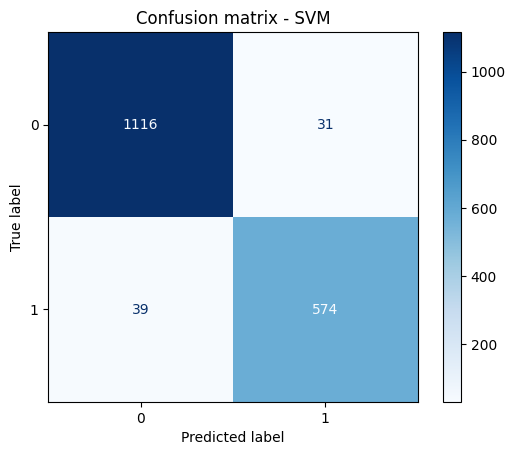

In [127]:
cm = confusion_matrix(y_test, y_test_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion matrix - SVM")
plt.show()

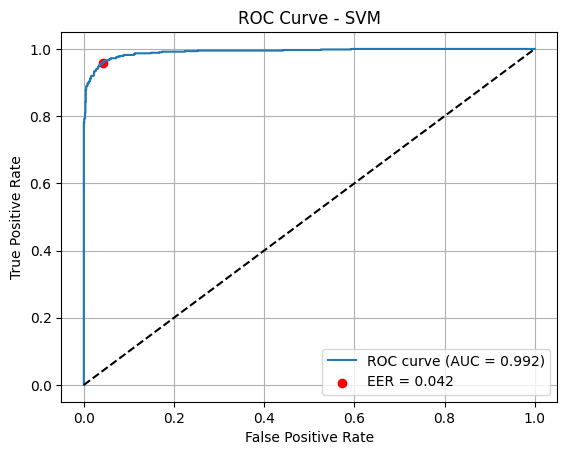

SVM - AUC: 0.992
SVM - EER: 0.042


In [128]:
y_score_svm = svm.decision_function(X_test_pca)
fpr, tpr, thresholds = roc_curve(y_test, y_score_svm)
auc_score = roc_auc_score(y_test, y_score_svm)
    
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.scatter(eer, 1 - eer, marker='o', color='red', label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid()
plt.show()
    
print(f"SVM - AUC: {auc_score:.3f}")
print(f"SVM - EER: {eer:.3f}")

## Random Forest

In [129]:
rf = RandomForestClassifier(n_estimators=100,min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=10, random_state=42)

In [130]:
y_val_pred_rf = rf.predict(X_val)
accuracy = accuracy_score(y_val, y_val_pred_rf)
precision = precision_score(y_val, y_val_pred_rf)
recall = recall_score(y_val, y_val_pred_rf)
f1 = f1_score(y_val, y_val_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9472
Precision: 0.9703
Recall: 0.8758
F1-score: 0.9206


In [134]:
y_test_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred_rf)
precision = precision_score(y_test, y_test_pred_rf)
recall = recall_score(y_test, y_test_pred_rf)
f1 = f1_score(y_test, y_test_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9398
Precision: 0.9756
Recall: 0.8483
F1-score: 0.9075


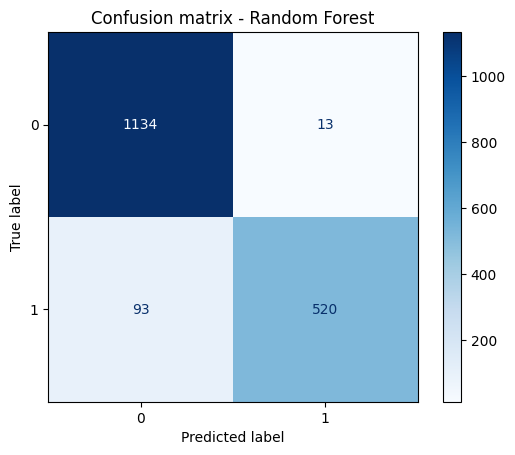

In [132]:
cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion matrix - Random Forest")
plt.show()

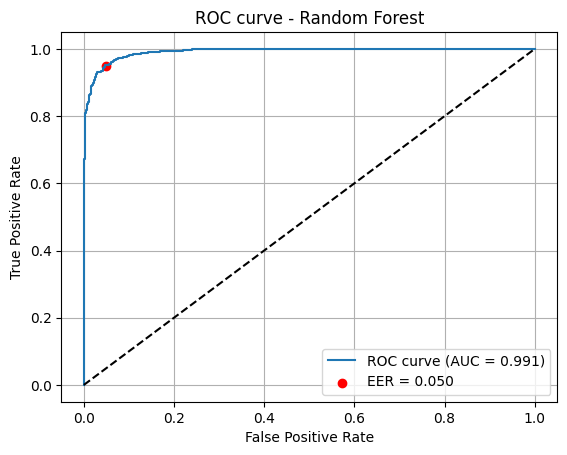

Random Forest - AUC: 0.991
Random Forest - EER: 0.050


In [133]:
y_score_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score_rf)
auc_score = roc_auc_score(y_test, y_score_rf)

fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.scatter(eer, 1 - eer, marker='o', color='red', label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()
    
print(f"Random Forest - AUC: {auc_score:.3f}")
print(f"Random Forest - EER: {eer:.3f}")